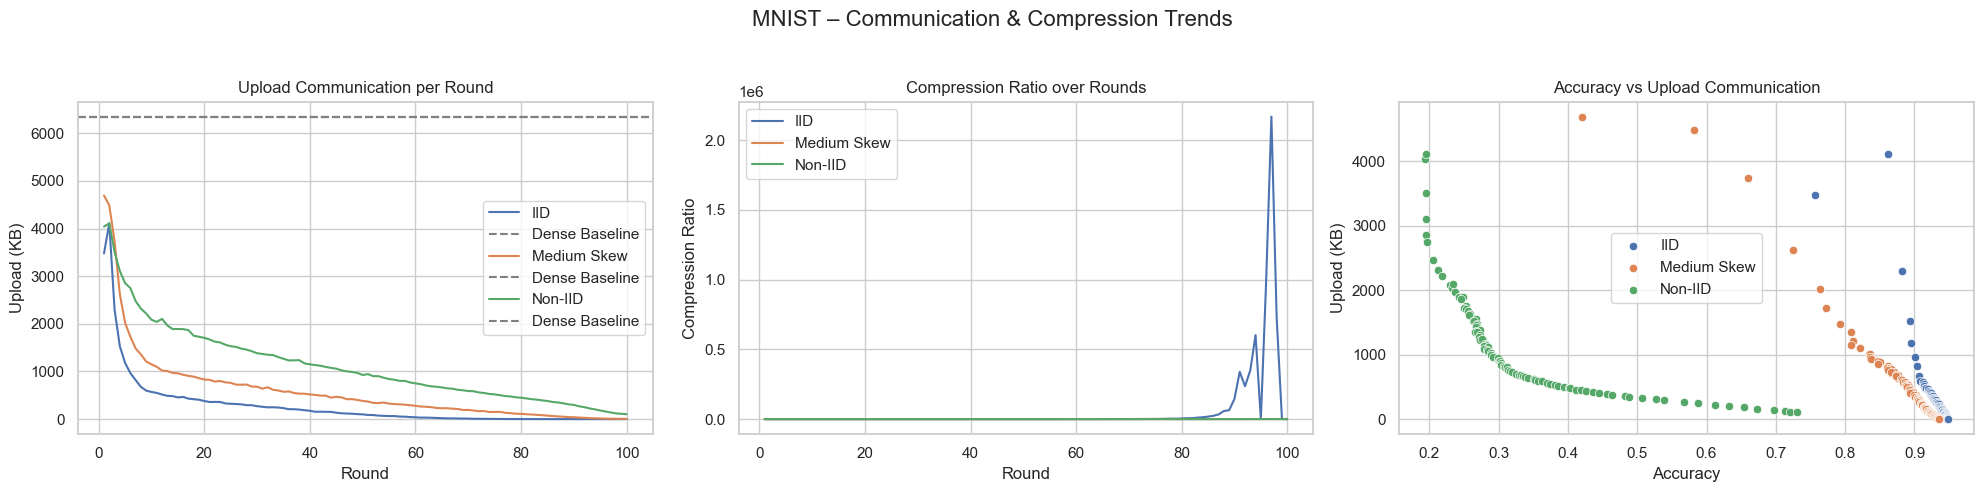

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# === UPDATE THESE FILE PATHS ===
DATASET_PATHS = {
    "MNIST": {
        "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\iid.csv",
        "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\medium.csv",
        "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\noniid.csv"
    }
    
}

partition_labels = {
    "iid": "IID",
    "medium": "Medium Skew",
    "noniid": "Non-IID"
}

def load_df(file_path):
    df = pd.read_csv(file_path)
    df["upload_KB"] = df["upload_bytes"] / 1024
    return df

def generate_dataset_subplots(dataset_name, paths):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"{dataset_name} – Communication & Compression Trends", fontsize=16)

    for i, (partition, file_path) in enumerate(paths.items()):
        df = load_df(file_path)

        # Subplot 1: Upload KB per Round
        sns.lineplot(data=df, x="round", y="upload_KB", ax=axes[0], label=partition_labels[partition])
        axes[0].axhline(y=df["model_size_bytes"].iloc[0] / 1024, color="gray", linestyle="--", label="Dense Baseline")
        axes[0].set_title("Upload Communication per Round")
        axes[0].set_xlabel("Round")
        axes[0].set_ylabel("Upload (KB)")

        # Subplot 2: Compression Ratio
        sns.lineplot(data=df, x="round", y="compression_ratio", ax=axes[1], label=partition_labels[partition])
        axes[1].set_title("Compression Ratio over Rounds")
        axes[1].set_xlabel("Round")
        axes[1].set_ylabel("Compression Ratio")

        # Subplot 3: Accuracy vs Upload KB
        sns.scatterplot(data=df, x="accuracy", y="upload_KB", ax=axes[2], label=partition_labels[partition])
        axes[2].set_title("Accuracy vs Upload Communication")
        axes[2].set_xlabel("Accuracy")
        axes[2].set_ylabel("Upload (KB)")

    for ax in axes:
        ax.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# === Run all datasets ===
for dataset, paths in DATASET_PATHS.items():
    generate_dataset_subplots(dataset, paths)


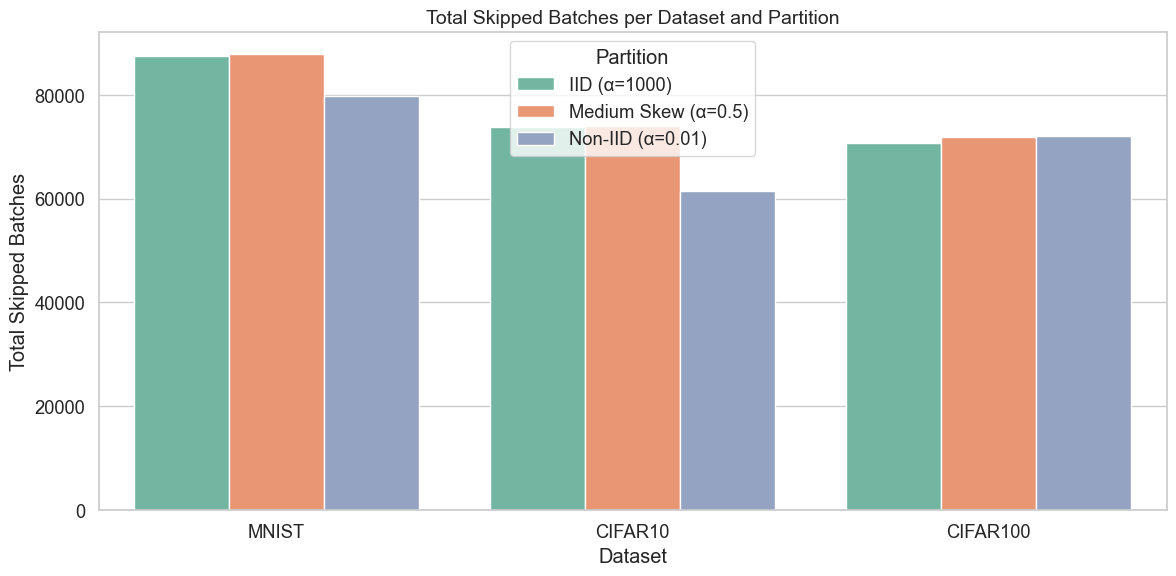

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🛠️ Replace with your actual file paths
fedtinyprop_logs = {
    "MNIST": {
        "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\MNIST\\fedtinyprop-v3\\iid.csv",
        "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\MNIST\\fedtinyprop-v3\\medium.csv",
        "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\MNIST\\fedtinyprop\\noniid.csv"
    },
    "CIFAR10": {
        "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR10\\fedtinyprop\\iid.csv",
        "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR10\\fedtinyprop\\medium.csv",
        "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR10\\fedtinyprop\\noniid.csv"
    },
    "CIFAR100": {
        "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR100\\fedtinyprop\\iid.csv",
        "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR100\\fedtinyprop\\medium.csv",
        "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR100\\fedtinyprop\\noniid.csv"
    }
}

# Mapping partition to label
partition_labels = {
    "iid": "IID (α=1000)",
    "medium": "Medium Skew (α=0.5)",
    "noniid": "Non-IID (α=0.01)"
}

# Collect skipped batches data
records = []
for dataset, partitions in fedtinyprop_logs.items():
    for partition, filepath in partitions.items():
        df = pd.read_csv(filepath)
        skipped = df["skipped_batches"].sum()
        records.append({
            "Dataset": dataset,
            "Partition": partition_labels[partition],
            "Skipped Batches": skipped
        })

plot_df = pd.DataFrame(records)

# 📊 Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Skipped Batches",
    hue="Partition",
    palette="Set2"
)
plt.title("Total Skipped Batches per Dataset and Partition", fontsize=14)
plt.xlabel("Dataset")
plt.ylabel("Total Skipped Batches")
plt.legend(title="Partition")
plt.tight_layout()
plt.show()


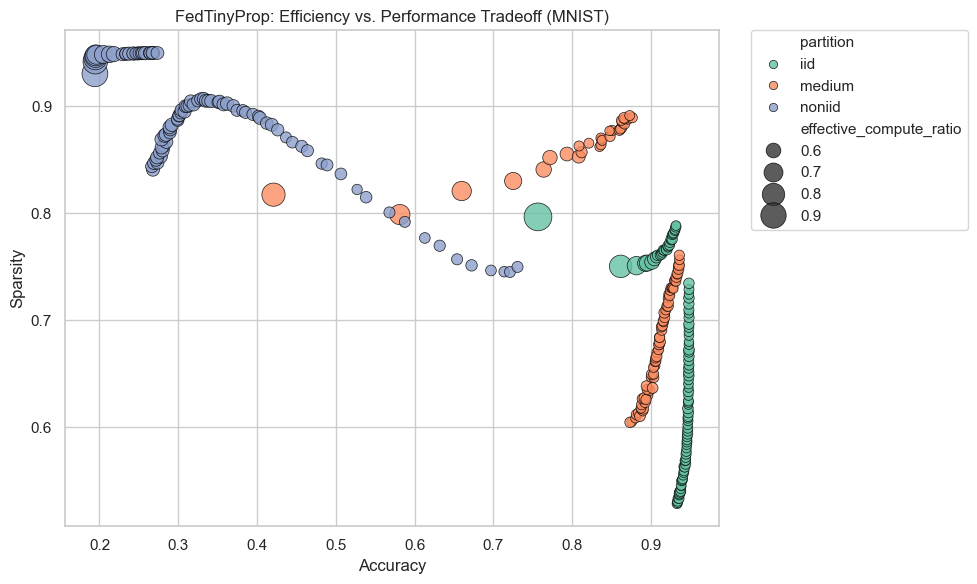

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Base directory for your dataset results
base_path = "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\MNIST\\fedtinyprop"

# Load all partition files and label them
partitions = ['iid', 'medium', 'noniid']
dfs = []

for part in partitions:
    file_path = os.path.join(base_path, f"{part}.csv")
    df = pd.read_csv(file_path)
    df['partition'] = part
    dfs.append(df)

# Concatenate into one DataFrame
full_df = pd.concat(dfs, ignore_index=True)

# Ensure proper types
full_df['accuracy'] = pd.to_numeric(full_df['accuracy'], errors='coerce')
full_df['sparsity'] = pd.to_numeric(full_df['sparsity'], errors='coerce')
full_df['effective_compute_ratio'] = pd.to_numeric(full_df['effective_compute_ratio'], errors='coerce')

# Drop NaNs just in case
full_df.dropna(subset=['accuracy', 'sparsity', 'effective_compute_ratio'], inplace=True)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=full_df,
    x="accuracy",
    y="sparsity",
    hue="partition",
    size="effective_compute_ratio",
    sizes=(40, 400),
    palette="Set2",
    alpha=0.8,
    edgecolor="black"
)

plt.xlabel("Accuracy")
plt.ylabel("Sparsity")
plt.title("FedTinyProp: Efficiency vs. Performance Tradeoff (MNIST)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


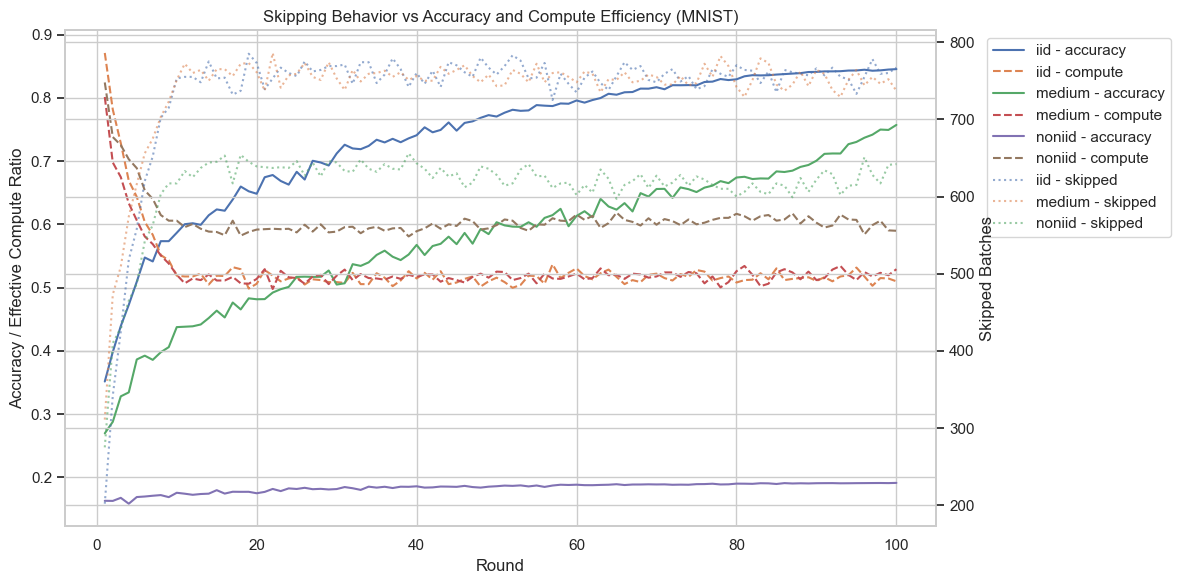

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Config
base_path = "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR10\\fedtinyprop"
partitions = ['iid', 'medium', 'noniid']
metrics = ['round', 'accuracy', 'skipped_batches', 'effective_compute_ratio']
dfs = []

# Plot
sns.set(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot accuracy and ECR on left Y-axis
for part in data['partition'].unique():
    part_df = data[data['partition'] == part]
    ax1.plot(part_df['round'], part_df['accuracy'], label=f"{part} - accuracy", linestyle="-")
    ax1.plot(part_df['round'], part_df['effective_compute_ratio'], label=f"{part} - compute", linestyle="--")

ax1.set_ylabel("Accuracy / Effective Compute Ratio")
ax1.set_xlabel("Round")

# Create second Y-axis
ax2 = ax1.twinx()
for part in data['partition'].unique():
    part_df = data[data['partition'] == part]
    ax2.plot(part_df['round'], part_df['skipped_batches'], label=f"{part} - skipped", linestyle=":", alpha=0.6)

ax2.set_ylabel("Skipped Batches")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Skipping Behavior vs Accuracy and Compute Efficiency (CIFAR10)")
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

# Replace with your actual CSV file path
csv_file_path = 'C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\FASHIONMNIST\\RigL\\iid.csv'

# Load the CSV
df = pd.read_csv(csv_file_path)

# Ensure the 'sparsity' column exists
if 'sparsity' not in df.columns:
    raise ValueError("The CSV file does not contain an 'sparsity' column.")

# Drop any missing values in 'sparsity'
sparsity_values = df['sparsity'].dropna()

# Compute average accuracy
average_sparsity = sparsity_values.mean()

# Print the result
print(f"Average Sparsity across all rounds: {average_sparsity:.4f}")


Average Sparsity across all rounds: 0.8917


In [34]:
import pandas as pd

# Replace with your actual CSV file path
csv_file_path = 'C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\FASHIONMNIST\\fedtinyprop\\noniid.csv'

# Load the CSV
df = pd.read_csv(csv_file_path)

# Ensure the 'flops' column exists
if 'flops' not in df.columns:
    raise ValueError("The CSV file does not contain a 'flops' column.")

# Drop any missing values in 'flops'
flops_values = df['flops'].dropna()

# Convert to GFLOPs and compute average
average_gflops = (flops_values / 1e9).mean()

# Print the result
print(f"Average Compute Cost across all rounds: {average_gflops:.2f} GFLOPs")


Average Compute Cost across all rounds: 1.89 GFLOPs


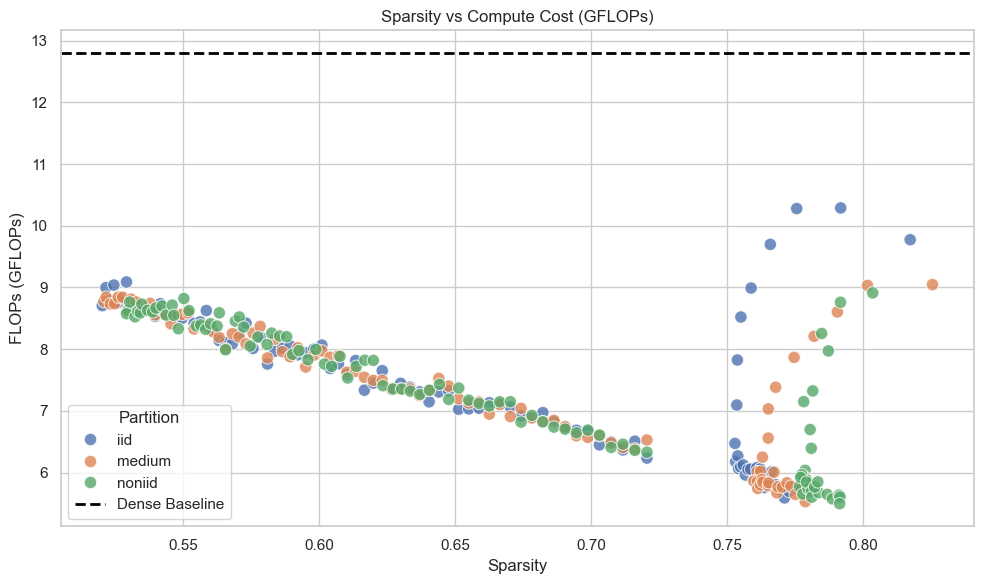

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load data
base_path = "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\CIFAR100\\fedtinyprop"
partitions = ['iid', 'medium', 'noniid']
metrics = ['round', 'sparsity', 'flops']
dfs = []
dense_flops = 12.8  # Example for MNIST
for part in partitions:
    file_path = os.path.join(base_path, f"{part}.csv")
    df = pd.read_csv(file_path)
    df['partition'] = part
    dfs.append(df[metrics + ['partition']])

df_all = pd.concat(dfs, ignore_index=True)

# Normalize FLOPs to GFLOPs if needed
if df_all['flops'].max() > 1e6:
    df_all['flops'] = df_all['flops'] / 1e9  # Convert to GFLOPs

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_all,
    x="sparsity",
    y="flops",
    hue="partition",
    alpha=0.8,
    s=80
)
plt.axhline(y=dense_flops, color='black', linestyle='--', linewidth=2, label="Dense Baseline")
plt.title("Sparsity vs Compute Cost (GFLOPs)")
plt.xlabel("Sparsity")
plt.ylabel("FLOPs (GFLOPs)")
plt.legend(title="Partition")
plt.tight_layout()
plt.show()


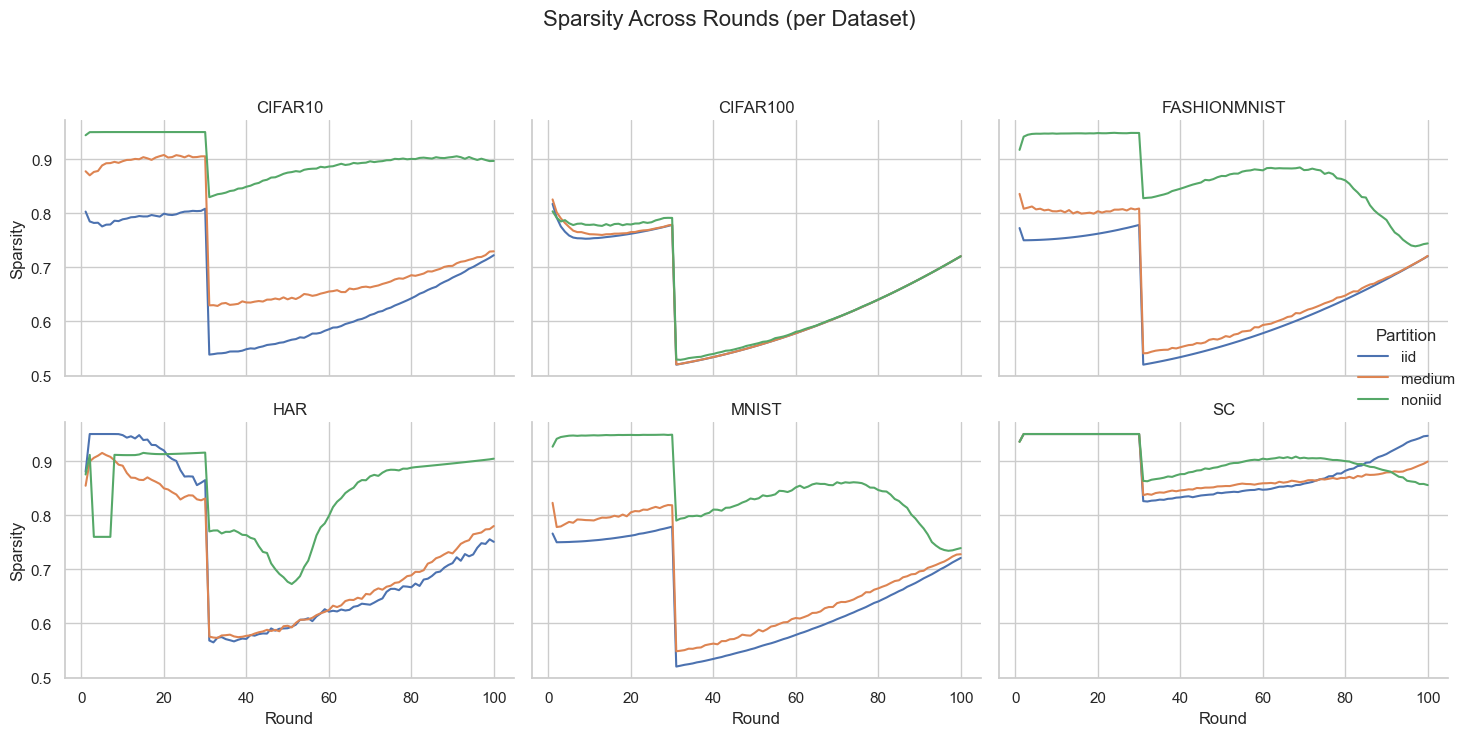

C:\Users\la7tim\AppData\Local\Temp\ipykernel_1976\4149505619.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skipped, y='label', x='skipped_batches', palette='viridis')


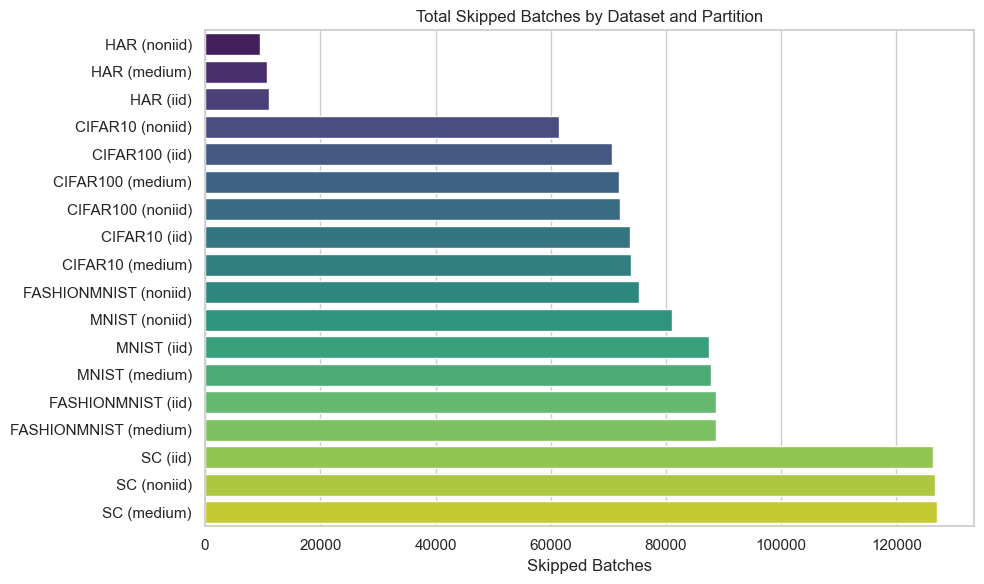

C:\Users\la7tim\AppData\Local\Temp\ipykernel_1976\4149505619.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='config', y='effective_compute_ratio', palette='Set3')


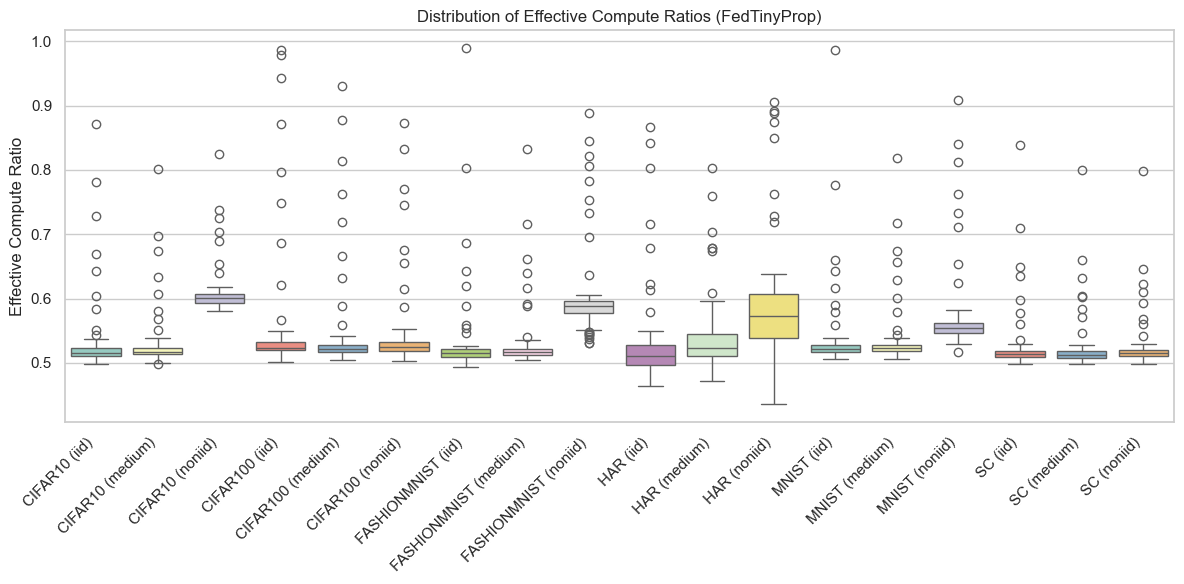

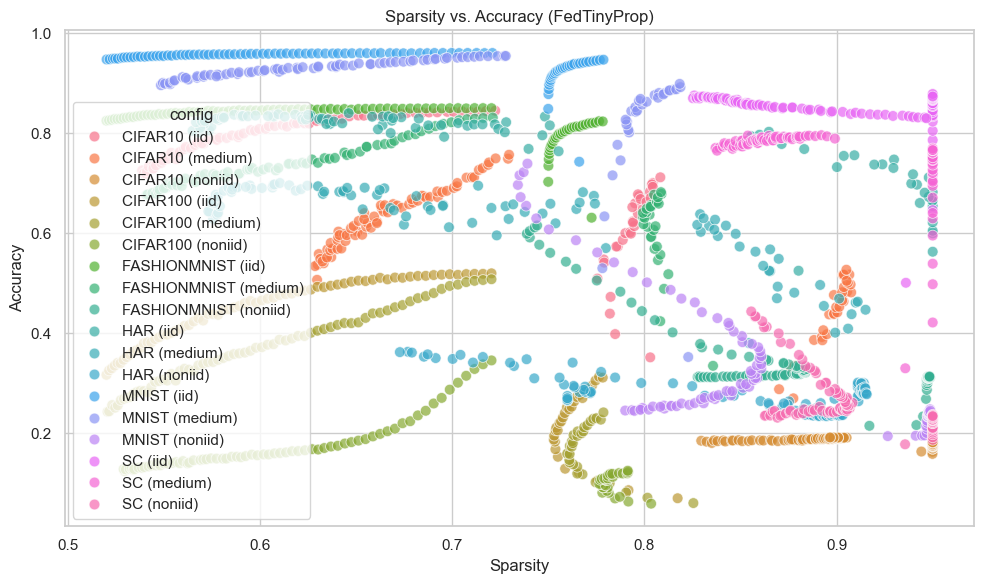

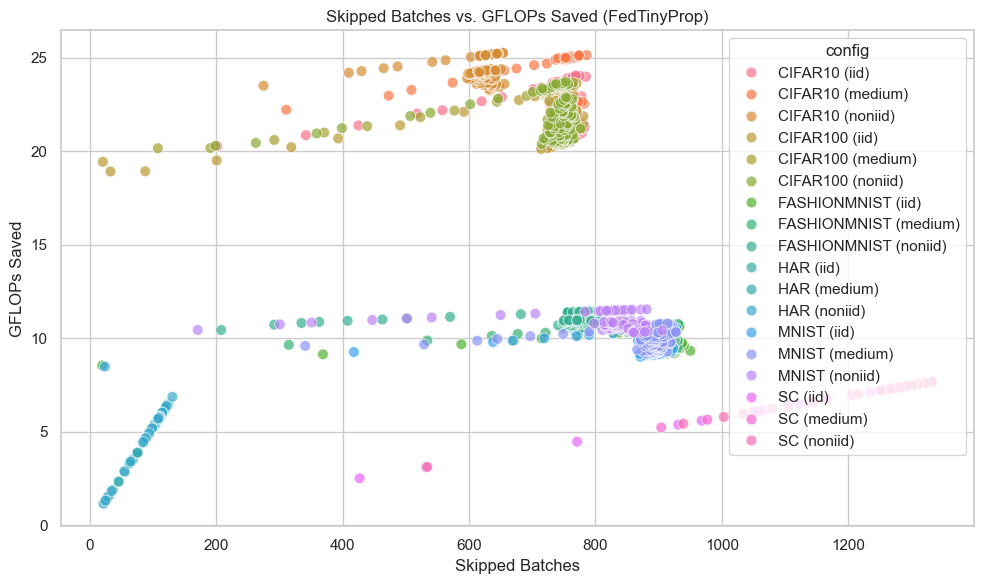

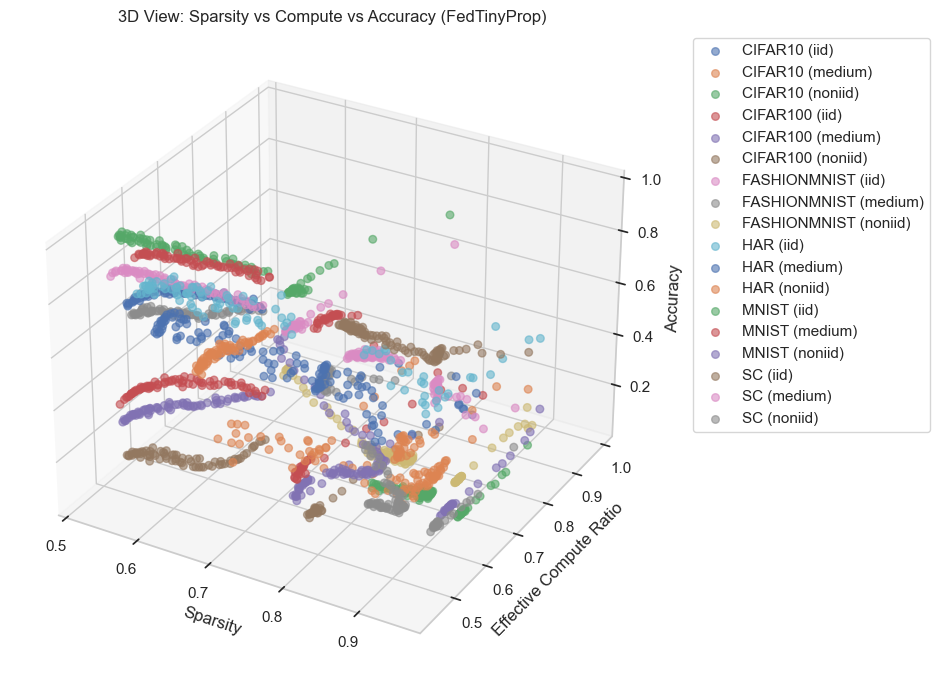

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# Base directory for result CSVs
base_dir = 'C:/Users/la7tim/Desktop/Internship/FedTinyProp/notebooks/results'

# Collect all CSV paths (update pattern if needed)
csv_paths = glob(os.path.join(base_dir, '*', '*', '*.csv'))

# Collect data into a unified DataFrame
all_dfs = []

for path in csv_paths:
    # Infer dataset, method, and partition from the path
    parts = path.replace("\\", "/").split('/')
    dataset, method, partition = parts[-3], parts[-2], parts[-1].replace('.csv', '')
    
    df = pd.read_csv(path)
    df['dataset'] = dataset
    df['method'] = method
    df['partition'] = partition
    all_dfs.append(df)

# Combine all
df_all = pd.concat(all_dfs, ignore_index=True)
df_all['gflops'] = df_all['flops'] / 1e9

# ========== 1. Smoothed Sparsity Trends ==========
g = sns.FacetGrid(df_all[df_all['method'] == 'fedtinyprop'], col="dataset", col_wrap=3, hue="partition", height=3.5, aspect=1.3)
g.map(sns.lineplot, "round", "sparsity")
g.add_legend(title='Partition')
g.set_axis_labels("Round", "Sparsity")
g.set_titles("{col_name}")
plt.suptitle("Sparsity Across Rounds (per Dataset)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


# ========== 2. Skipped Batches Bar Plot ==========
skipped = df_all[df_all['method'] == 'fedtinyprop'].groupby(['dataset', 'partition'])['skipped_batches'].sum().reset_index()
skipped['label'] = skipped['dataset'] + ' (' + skipped['partition'] + ')'
skipped = skipped.sort_values(by='skipped_batches')

plt.figure(figsize=(10, 6))
sns.barplot(data=skipped, y='label', x='skipped_batches', palette='viridis')
plt.title('Total Skipped Batches by Dataset and Partition')
plt.xlabel('Skipped Batches')
plt.ylabel('')
plt.tight_layout()
plt.show()


# ========== 3. Smoothed Effective Compute Ratio ==========
df_plot = df_all[df_all['method'] == 'fedtinyprop'].copy()
df_plot['config'] = df_plot['dataset'] + ' (' + df_plot['partition'] + ')'

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='config', y='effective_compute_ratio', palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Effective Compute Ratios (FedTinyProp)')
plt.ylabel('Effective Compute Ratio')
plt.xlabel('')
plt.tight_layout()
plt.show()

# ========= 4. Sparsity vs. Accuracy Scatter Plot =========
accuracy_col = next((col for col in df_all.columns if 'accuracy' in col.lower()), None)

df_filtered = df_all[df_all['method'] == 'fedtinyprop'].copy()
df_filtered['config'] = df_filtered['dataset'] + ' (' + df_filtered['partition'] + ')'

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='sparsity', y=accuracy_col, hue='config', alpha=0.7, edgecolor='w', s=60)
plt.title('Sparsity vs. Accuracy (FedTinyProp)')
plt.xlabel('Sparsity')
plt.ylabel(accuracy_col.replace('_', ' ').title())
plt.grid(True)
plt.tight_layout()
plt.show()

# ========= 5. Skipped Batches vs. GFLOPs Saved =========
# Compute average dense GFLOPs per (dataset, partition)
dense_df = df_all[df_all['method'] == 'dense']
dense_gflops = dense_df.groupby(['dataset', 'partition'])['gflops'].mean().to_dict()

# Calculate GFLOPs saved
df_filtered['dense_gflops'] = df_filtered.apply(
    lambda row: dense_gflops.get((row['dataset'], row['partition']), None), axis=1
)
df_filtered['gflops_saved'] = df_filtered['dense_gflops'] - df_filtered['gflops']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='skipped_batches', y='gflops_saved', hue='config', alpha=0.7, edgecolor='w', s=60)
plt.title('Skipped Batches vs. GFLOPs Saved (FedTinyProp)')
plt.xlabel('Skipped Batches')
plt.ylabel('GFLOPs Saved')
plt.grid(True)
plt.tight_layout()
plt.show()

# ========= 6. 3D Plot: Accuracy vs. Sparsity vs. Compute =========
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for name, group in df_filtered.groupby('config'):
    ax.scatter(group['sparsity'], group['effective_compute_ratio'], group[accuracy_col],
               label=name, s=30, alpha=0.6)

ax.set_xlabel('Sparsity')
ax.set_ylabel('Effective Compute Ratio')
ax.set_zlabel(accuracy_col.replace('_', ' ').title())
ax.set_title('3D View: Sparsity vs Compute vs Accuracy (FedTinyProp)')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.tight_layout()
plt.show()


C:\Users\la7tim\AppData\Local\Temp\ipykernel_1976\1666856110.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='config', y='effective_compute_ratio', palette='Set3')


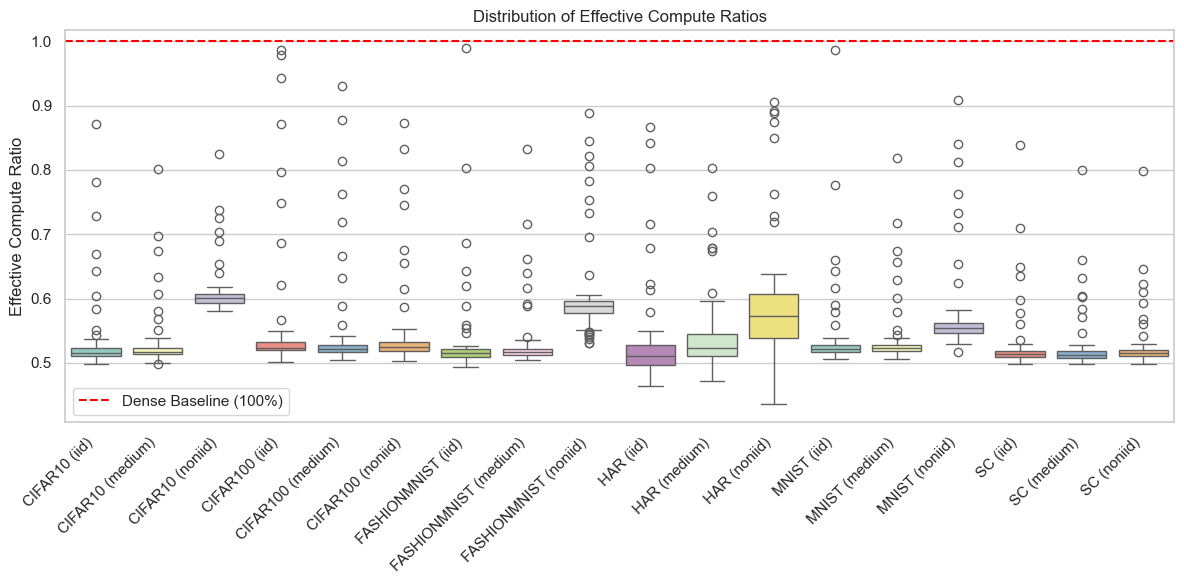

In [103]:
# ========== 3. Smoothed Effective Compute Ratio with Dense Line ==========
df_plot = df_all[df_all['method'] == 'fedtinyprop'].copy()
df_plot['config'] = df_plot['dataset'] + ' (' + df_plot['partition'] + ')'

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='config', y='effective_compute_ratio', palette='Set3')

# Add horizontal line at y=1.0 to indicate dense compute
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Dense Baseline (100%)')

plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Effective Compute Ratios')
plt.ylabel('Effective Compute Ratio')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()


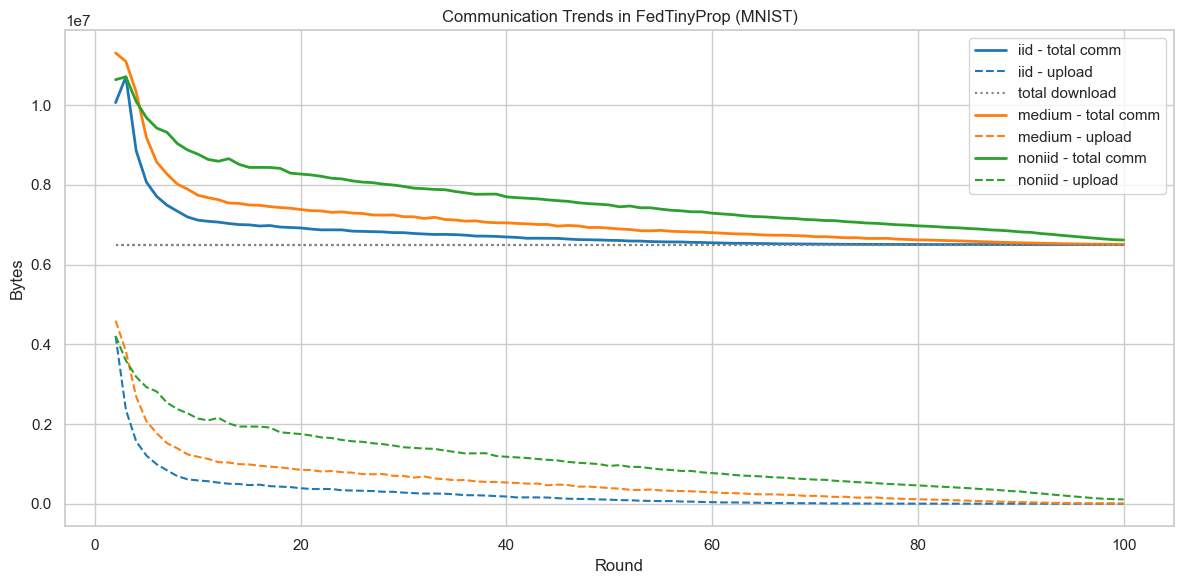

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths for MNIST
paths = {
    "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\iid.csv",
    "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\medium.csv",
    "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\noniid.csv"
}

plt.figure(figsize=(12, 6))
plotted_download = False  # Flag to plot 'total download' label only once

for partition, path in paths.items():
    df = pd.read_csv(path)
    df = df.dropna(subset=['round', 'communication', 'upload_bytes', 'download_bytes'])

    # Skip round 1
    df = df[df['round'] > 1]

    # Plot total communication
    plt.plot(df['round'], df['communication'], label=f"{partition} - total comm", color=colors[partition], linewidth=2)

    # Plot upload bytes
    plt.plot(df['round'], df['upload_bytes'], label=f"{partition} - upload", color=colors[partition], linestyle='--')

    # Plot constant download line only once
    if not plotted_download:
        download_mean = df['download_bytes'].mean()
        plt.hlines(y=download_mean, xmin=df['round'].min(), xmax=df['round'].max(),
                   colors='gray', linestyles='dotted', label='total download')
        plotted_download = True
    else:
        # Still draw the line but without a legend label
        plt.hlines(y=download_mean, xmin=df['round'].min(), xmax=df['round'].max(),
                   colors='gray', linestyles='dotted', label=None)

plt.title("Communication Trends in FedTinyProp (MNIST)")
plt.xlabel("Round")
plt.ylabel("Bytes")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


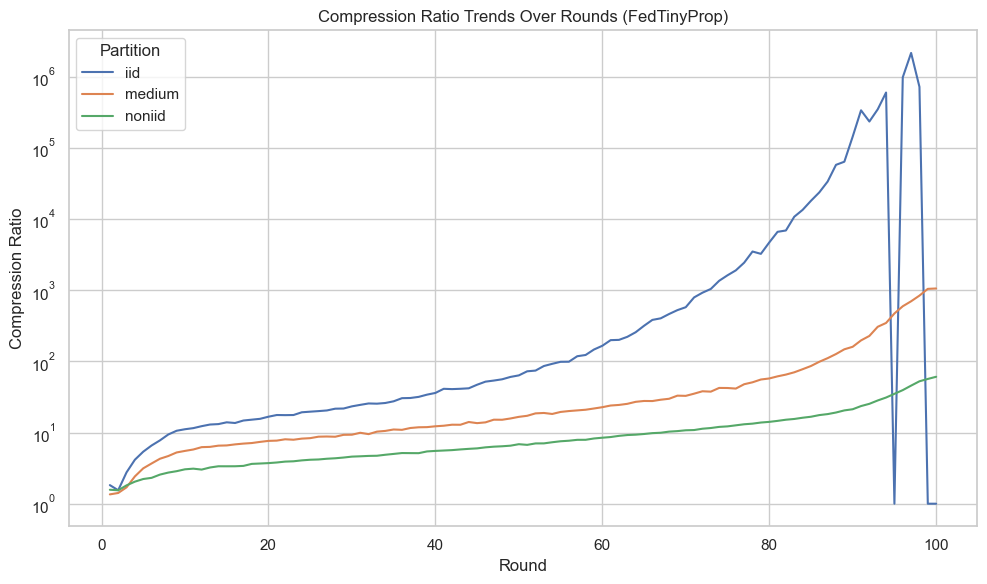

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# Example using MNIST data from 3 partitions
paths = {
    "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\iid.csv",
    "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\medium.csv",
    "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\fedtinyprop\\noniid.csv"
}

plt.figure(figsize=(10, 6))

for name, path in paths.items():
    df = pd.read_csv(path)
    plt.plot(df['round'], df['compression_ratio'], label=name)

plt.xlabel("Round")
plt.ylabel("Compression Ratio")
plt.title("Compression Ratio Trends Over Rounds (FedTinyProp)")
plt.legend(title="Partition")
plt.grid(True)
plt.tight_layout()
plt.yscale("log")

plt.show()


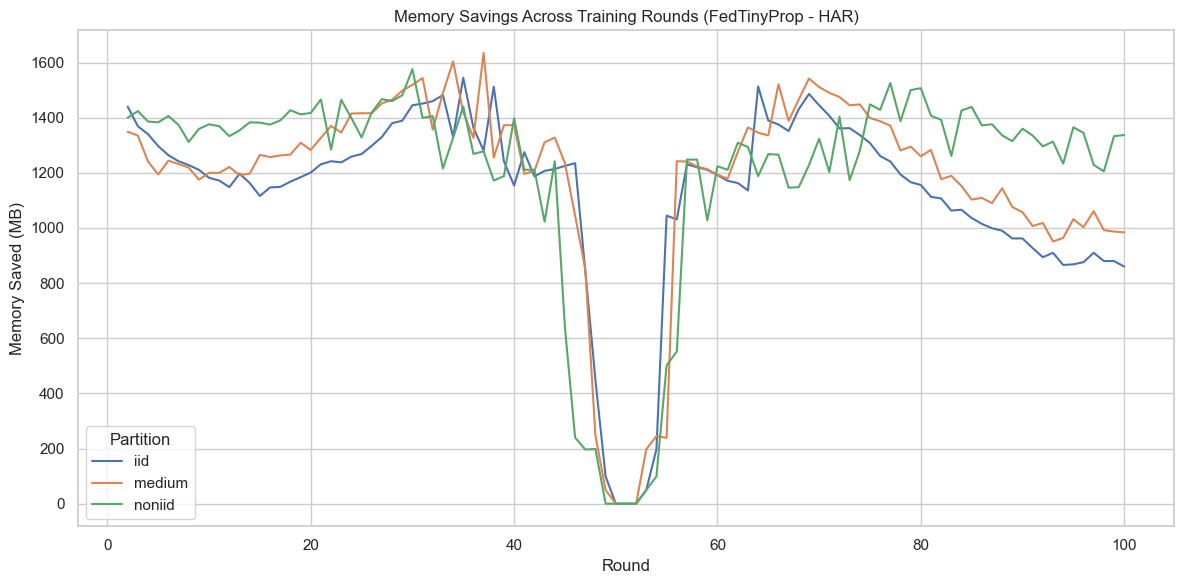

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# Define CSV paths for MNIST under three partitions
paths = {
    "iid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\HAR\\dense\\iid.csv",
    "medium": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\HAR\\dense\\medium.csv",
    "noniid": "C:\\Users\\la7tim\\Desktop\\Internship\\FedTinyProp\\notebooks\\results\\HAR\\dense\\noniid.csv"
}

plt.figure(figsize=(12, 6))

# Plot memory saved across rounds for each partition
for partition, path in paths.items():
    df = pd.read_csv(path)
    df = df[df['round'] > 1]  # Skip round 1
    plt.plot(df['round'], df['memory_saved'], label=partition)

# Labels and title
plt.title("Memory Savings Across Training Rounds (FedTinyProp - HAR)")
plt.xlabel("Round")
plt.ylabel("Memory Saved (MB)")
plt.legend(title="Partition")
plt.grid(True)
plt.tight_layout()
plt.show()
